# Analyse des données de friches - friches-standard.csv

Ce notebook présente une analyse exploratoire des données contenues dans le fichier `data/friches-standard.csv`.

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## 1. Chargement des données

In [2]:
# Chargement des données depuis le fichier CSV
df = pd.read_csv('../data/friches-standard.csv', sep=';', encoding='utf-8', low_memory=False)

print(f"Données chargées avec succès !")
print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")

Données chargées avec succès !
Nombre de lignes : 28,728
Nombre de colonnes : 50


## 2. Aperçu des données

In [3]:
# Affichage des premières lignes
print("=== Premières lignes du dataset ===")
df.head(10)

=== Premières lignes du dataset ===


,site_id,site_nom,site_type,site_adresse,site_identif_date,site_actu_date,site_url,site_ademe_url,site_securite,site_occupation,...,urba_zone_formdomi,urba_doc_type,desserte_distance,desserte_commentaire,source_nom,source_url,source_producteur,source_contact,geompoint,geomsurf
0,03095_17913,Anc. Décharge Communale OM de Meunière,inconnu,NaN,2022-10-10,2022-10-10,http://fiches-risques.brgm.fr/georisques/basia...,NaN,inconnu,inconnu,...,NaN,PLU,NaN,NaN,Site Basias ou Basol non vérifié par le Cerema,https://www.data.gouv.fr/fr/datasets/inventair...,lou dupont,NaN,POINT (3.469862 46.13434),NaN
1,06085_16087,Serrurerie et garage,inconnu,NaN,2022-10-10,2022-10-10,http://fiches-risques.brgm.fr/georisques/basia...,NaN,inconnu,inconnu,...,NaN,PLU,NaN,NaN,Site Basias ou Basol non vérifié par le Cerema,https://www.data.gouv.fr/fr/datasets/inventair...,lou dupont,NaN,POINT (6.999754 43.58304),NaN
2,06088_10998,Appel à projet Recyclage Foncier 2021 2nde édi...,mixte,NaN,2021-12-01,2021-12-01,NaN,NaN,inconnu,inconnu,...,NaN,PLUI,NaN,NaN,Appel à projet Fonds Friches,https://www.economie.gouv.fr/plan-de-relance/p...,Appel à projet Fonds Friches,NaN,POINT (7.203463 43.67994),NaN
3,76175_26890,Maison rue du val Ricard,friche d'habitat,NaN,2022-11-28,2022-11-28,NaN,NaN,NaN,inconnu,...,NaN,NaN,NaN,NaN,EPF Normandie,NaN,EPF Normandie,NaN,POINT (1.44829 49.80831),NaN
4,06088_16211,Blanchisserie,inconnu,NaN,2022-10-10,2022-10-10,http://fiches-risques.brgm.fr/georisques/basia...,NaN,inconnu,inconnu,...,NaN,PLUI,NaN,NaN,Site Basias ou Basol non vérifié par le Cerema,https://www.data.gouv.fr/fr/datasets/inventair...,lou dupont,NaN,POINT (7.227269 43.71092),NaN
5,52465_36246,Auberge du Col du Hantz,friche commerciale,route du Hantz,2025-01-01,2025-10-01,NaN,NaN,NaN,NaN,...,NaN,PLU,NaN,NaN,NaN,NaN,DDT 67,NaN,POINT (7.089416 48.40237),NaN
6,06088_29121,Dépôt de bitume,inconnu,NaN,2024-08-09,2024-08-09,NaN,NaN,inconnu,inconnu,...,NaN,PLUI,NaN,NaN,Sud Foncier Eco,https://sudfonciereco.maregionsud.fr/,Sud Foncier Eco,NaN,POINT (7.243596 43.71449),NaN
7,06088_6374,Zac Méridia - lot 2.5a,inconnu,NaN,2022-10-10,2022-10-10,NaN,NaN,inconnu,inconnu,...,NaN,PLUI,NaN,NaN,Contributeur Cerema,NaN,Contributeur Cerema,NaN,POINT (7.199612 43.68189),NaN
8,06088_9317,Fonderie des métaux et des alliages,inconnu,NaN,2022-10-10,2022-10-10,http://fiches-risques.brgm.fr/georisques/basia...,NaN,inconnu,inconnu,...,NaN,PLUI,NaN,NaN,Site Basias ou Basol non vérifié par le Cerema,https://www.data.gouv.fr/fr/datasets/inventair...,lou dupont,NaN,POINT (7.286279 43.71845),NaN
9,60506_36042,Valorisation de la friche ABEX,friche industrielle,370 rue de la Libération,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,urbanvitaliz,NaN,POINT (2.986941 49.56997),NaN


In [4]:
# Informations sur les colonnes
print("=== Informations sur les colonnes ===")
df.info()

=== Informations sur les colonnes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28728 entries, 0 to 28727
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   site_id                    28728 non-null  object 
 1   site_nom                   28728 non-null  object 
 2   site_type                  28728 non-null  object 
 3   site_adresse               4880 non-null   object 
 4   site_identif_date          28574 non-null  object 
 5   site_actu_date             28044 non-null  object 
 6   site_url                   16782 non-null  object 
 7   site_ademe_url             0 non-null      float64
 8   site_securite              21808 non-null  object 
 9   site_occupation            27630 non-null  object 
 10  site_statut                28728 non-null  object 
 11  site_projet_url            0 non-null      float64
 12  site_reconv_annee          0 non-null      float64
 13  site_rec

In [5]:
# Liste des colonnes disponibles
print("=== Liste des colonnes ===")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

=== Liste des colonnes ===
 1. site_id
 2. site_nom
 3. site_type
 4. site_adresse
 5. site_identif_date
 6. site_actu_date
 7. site_url
 8. site_ademe_url
 9. site_securite
10. site_occupation
11. site_statut
12. site_projet_url
13. site_reconv_annee
14. site_reconv_type
15. activite_libelle
16. activite_code
17. activite_fin_annee
18. comm_nom
19. comm_insee
20. bati_type
21. bati_nombre
22. bati_surface
23. bati_pollution
24. bati_vacance
25. bati_patrimoine
26. bati_etat
27. local_ancien_annee
28. local_recent_annee
29. proprio_type
30. proprio_personne
31. proprio_nom
32. sol_pollution_annee
33. sol_pollution_existe
34. sol_pollution_origine
35. sol_pollution_commentaire
36. sol_depollution_fiche
37. unite_fonciere_surface
38. unite_fonciere_refcad
39. urba_zone_type
40. urba_zone_lib
41. urba_zone_formdomi
42. urba_doc_type
43. desserte_distance
44. desserte_commentaire
45. source_nom
46. source_url
47. source_producteur
48. source_contact
49. geompoint
50. geomsurf


## 3. Analyse des valeurs manquantes

In [6]:
# Calcul des valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Valeurs_manquantes': df.isnull().sum(),
    'Pourcentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Valeurs_manquantes'] > 0].sort_values('Pourcentage', ascending=False)

print(f"=== Colonnes avec valeurs manquantes (sur {len(df.columns)} colonnes) ===\n")
print(missing_data.to_string(index=False))

=== Colonnes avec valeurs manquantes (sur 50 colonnes) ===

                  Colonne  Valeurs_manquantes  Pourcentage
                 geomsurf               28728       100.00
     desserte_commentaire               28728       100.00
           site_ademe_url               28728       100.00
        desserte_distance               28728       100.00
          site_projet_url               28728       100.00
        site_reconv_annee               28728       100.00
sol_pollution_commentaire               28728       100.00
      sol_pollution_annee               28728       100.00
    sol_depollution_fiche               28725        99.99
             bati_surface               28708        99.93
            activite_code               28574        99.46
           source_contact               26392        91.87
         site_reconv_type               25968        90.39
       activite_fin_annee               24722        86.06
       urba_zone_formdomi               24345        84

## 4. Analyse des types de friches

=== Types de friches ===
inconnu                              15995
friche d'habitat                      4014
friche industrielle                   2958
friche commerciale                    1292
autre                                 1223
mixte                                  743
friche d'équipement public             699
friche ferroviaire                     430
friche agro-industrielle               361
friche loisir tourisme hôtellerie      221
friche logistique                      210
friche hospitalière                    180
friche carrière ou mine                168
friche militaire                       160
friche enseignement                     40
friche cultuelle                        20
friche aéroportuaire                     7
friche portuaire                         4
friche culturelle                        2
friche touristique                       1
Name: site_type, dtype: int64


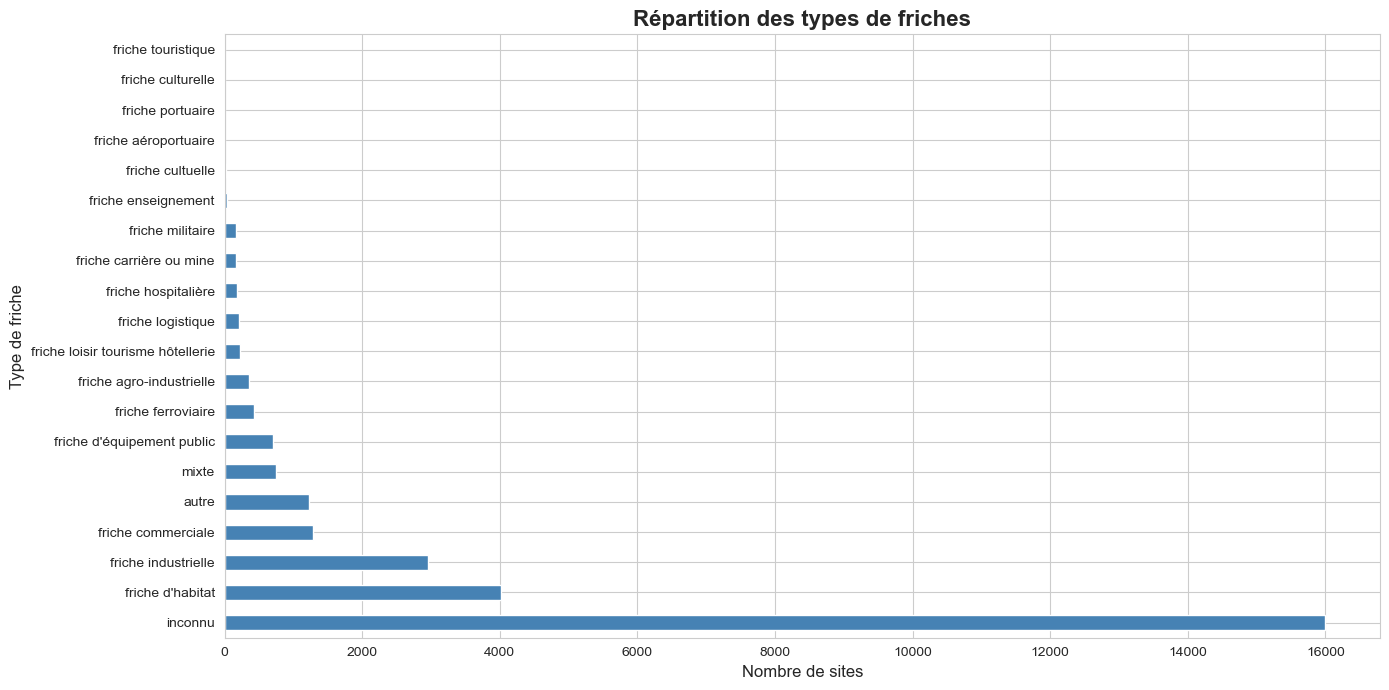

In [7]:
# Analyse des types de friches
print("=== Types de friches ===")
type_counts = df['site_type'].value_counts()
print(type_counts)

# Visualisation
plt.figure(figsize=(14, 7))
type_counts.plot(kind='barh', color='steelblue')
plt.title('Répartition des types de friches', fontsize=16, fontweight='bold')
plt.xlabel('Nombre de sites', fontsize=12)
plt.ylabel('Type de friche', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Analyse des statuts de friches

=== Statuts des friches ===
friche potentielle    13309
friche sans projet     8996
friche avec projet     5696
friche reconvertie      727
Name: site_statut, dtype: int64


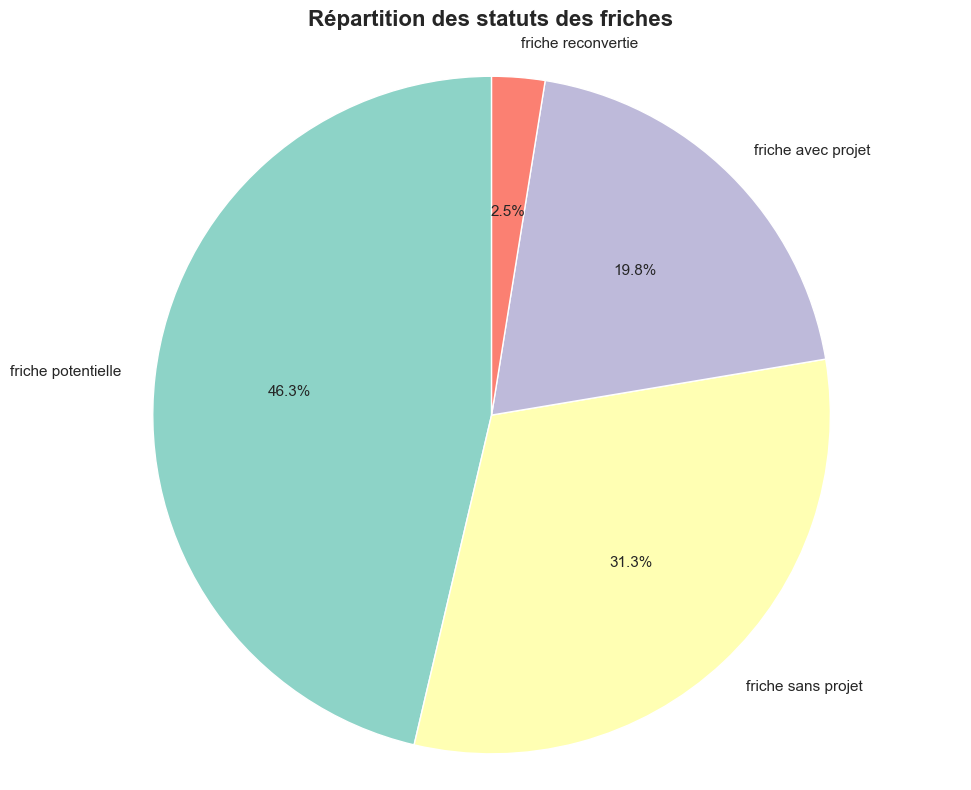

In [8]:
# Analyse des statuts
print("=== Statuts des friches ===")
statut_counts = df['site_statut'].value_counts()
print(statut_counts)

# Visualisation en camembert
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(statut_counts)))
plt.pie(statut_counts.values, labels=statut_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 11})
plt.title('Répartition des statuts des friches', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

## 6. Analyse géographique - Top 10 des communes

=== Top 10 des communes avec le plus de friches ===
ANGOULEME            697
MARSEILLE            162
ROUBAIX              159
LILLE                138
LA COURONNE          122
RUELLE-SUR-TOUVRE    118
GOND-PONTOUVRE        94
SOYAUX                90
GRAULHET              86
TOURCOING             86
Name: comm_nom, dtype: int64


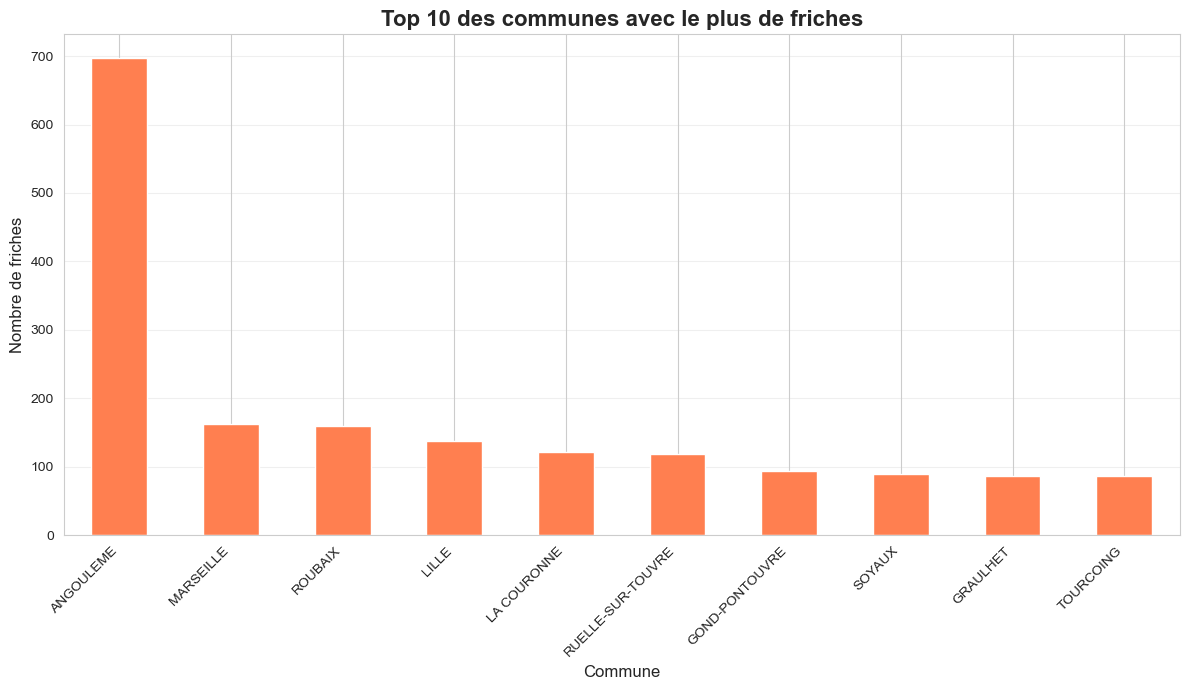

In [9]:
# Top 10 des communes avec le plus de friches
print("=== Top 10 des communes avec le plus de friches ===")
top_communes = df['comm_nom'].value_counts().head(10)
print(top_communes)

# Visualisation
plt.figure(figsize=(12, 7))
top_communes.plot(kind='bar', color='coral')
plt.title('Top 10 des communes avec le plus de friches', fontsize=16, fontweight='bold')
plt.xlabel('Commune', fontsize=12)
plt.ylabel('Nombre de friches', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Analyse de la pollution

=== Pollution du sol ===
inconnu                   24537
pollution supposée         1629
pollution peu probable      836
pollution inexistante       526
pollution avérée            480
pollution traitée             8
pollution probable            2
Name: sol_pollution_existe, dtype: int64

=== Pollution du bâtiment ===
inconnu       26297
amiante        1189
autre           126
sans objet       65
plomb            21
probable          1
Name: bati_pollution, dtype: int64


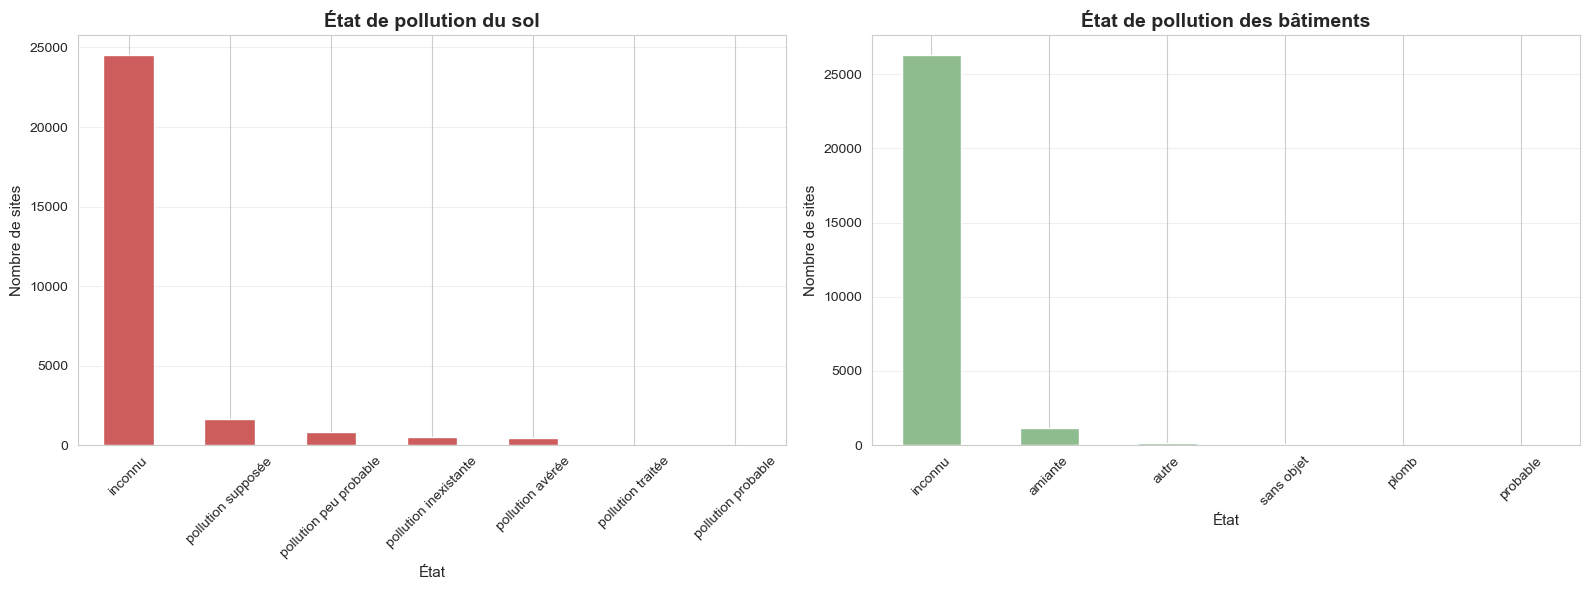

In [10]:
# Analyse de la pollution des sols et bâtiments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pollution du sol
print("=== Pollution du sol ===")
sol_pollution = df['sol_pollution_existe'].value_counts()
print(sol_pollution)
print()

ax1 = axes[0]
sol_pollution.plot(kind='bar', ax=ax1, color='indianred')
ax1.set_title('État de pollution du sol', fontsize=14, fontweight='bold')
ax1.set_xlabel('État', fontsize=11)
ax1.set_ylabel('Nombre de sites', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Pollution du bâtiment
print("=== Pollution du bâtiment ===")
bati_pollution = df['bati_pollution'].value_counts()
print(bati_pollution)

ax2 = axes[1]
bati_pollution.plot(kind='bar', ax=ax2, color='darkseagreen')
ax2.set_title('État de pollution des bâtiments', fontsize=14, fontweight='bold')
ax2.set_xlabel('État', fontsize=11)
ax2.set_ylabel('Nombre de sites', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Analyse des propriétaires

=== Types de propriétaires ===
personne morale      16865
personne physique    10441
autre                 1006
inconnu                 18
Name: proprio_personne, dtype: int64


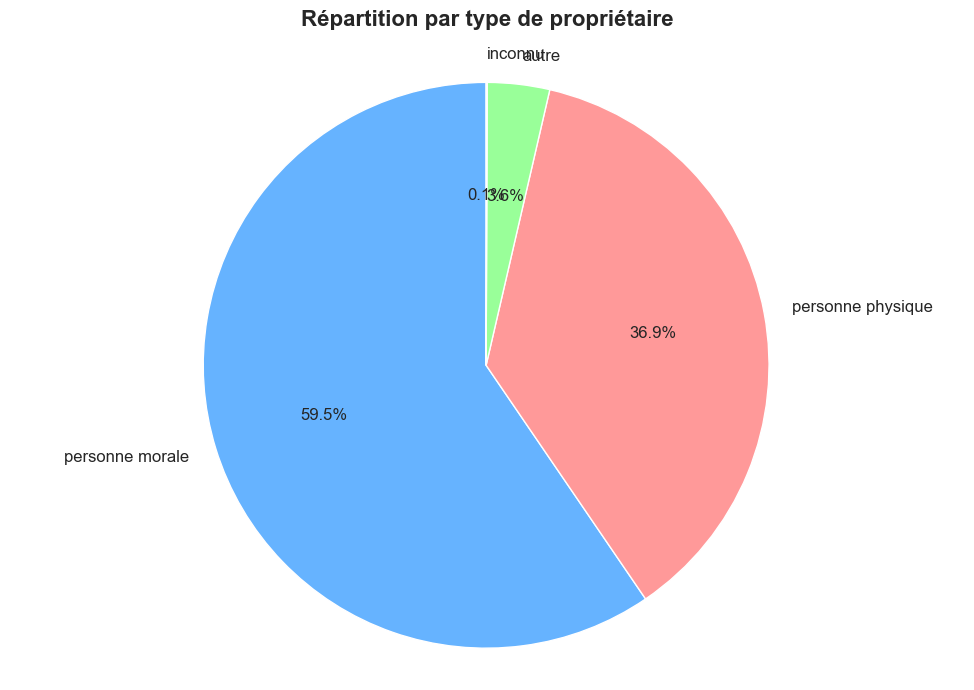

In [11]:
# Analyse des types de propriétaires
print("=== Types de propriétaires ===")
proprio_type = df['proprio_personne'].value_counts()
print(proprio_type)

# Visualisation
plt.figure(figsize=(10, 7))
colors = ['#66b3ff', '#ff9999', '#99ff99', '#ffcc99']
plt.pie(proprio_type.values, labels=proprio_type.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize':12})
plt.title('Répartition par type de propriétaire', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

## 9. Analyse des surfaces

=== Statistiques des surfaces (en m²) ===
count    2.831600e+04
mean     1.116046e+05
std      1.179655e+06
min      1.000000e+00
25%      1.577000e+03
50%      7.623500e+03
75%      3.680450e+04
max      1.340958e+08
Name: unite_fonciere_surface_num, dtype: float64

Surface totale : 3,160,197,256 m²
Surface médiane : 7,624 m²


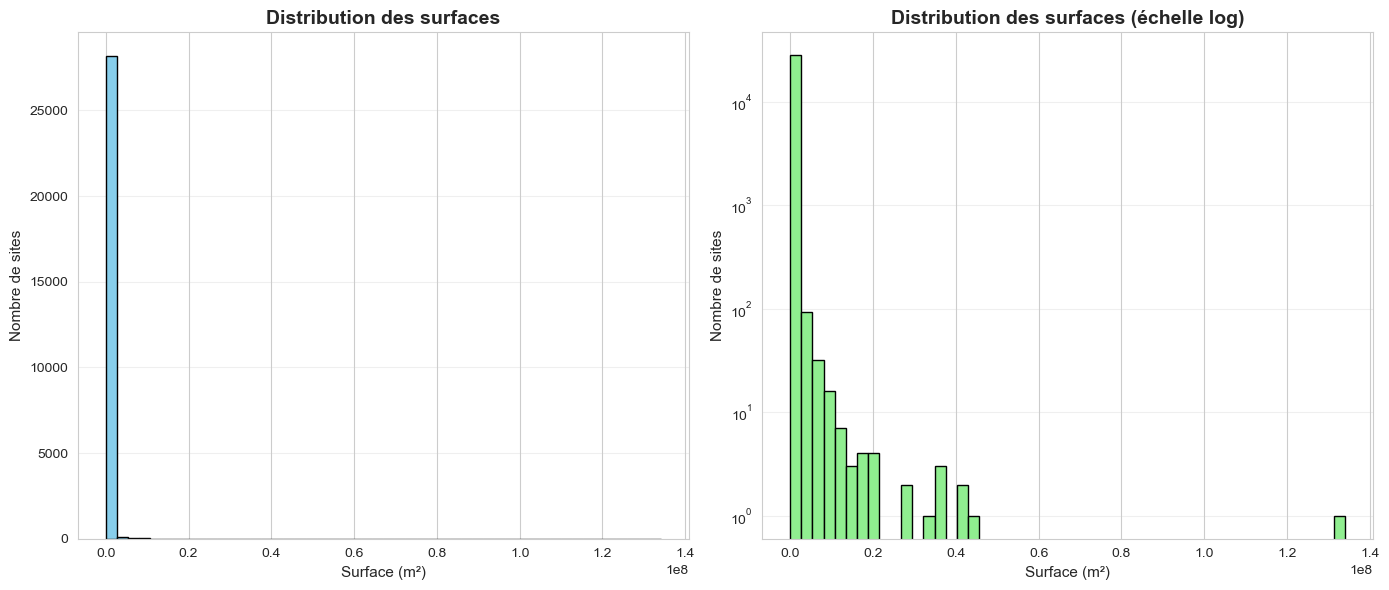

In [12]:
# Analyse des surfaces des unités foncières
df['unite_fonciere_surface_num'] = pd.to_numeric(df['unite_fonciere_surface'], errors='coerce')

# Statistiques descriptives
print("=== Statistiques des surfaces (en m²) ===")
surface_stats = df['unite_fonciere_surface_num'].describe()
print(surface_stats)
print(f"\nSurface totale : {df['unite_fonciere_surface_num'].sum():,.0f} m²")
print(f"Surface médiane : {df['unite_fonciere_surface_num'].median():,.0f} m²")

# Visualisation de la distribution
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
df['unite_fonciere_surface_num'].dropna().hist(bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution des surfaces', fontsize=14, fontweight='bold')
plt.xlabel('Surface (m²)', fontsize=11)
plt.ylabel('Nombre de sites', fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
# Utiliser une échelle log pour mieux voir la distribution
df['unite_fonciere_surface_num'].dropna().hist(bins=50, edgecolor='black', color='lightgreen')
plt.title('Distribution des surfaces (échelle log)', fontsize=14, fontweight='bold')
plt.xlabel('Surface (m²)', fontsize=11)
plt.ylabel('Nombre de sites', fontsize=11)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Résumé statistique général

In [13]:
# Résumé général
print("=" * 70)
print("                   RÉSUMÉ DE L'ANALYSE DES FRICHES")
print("=" * 70)
print()
print(f"📊 Nombre total de friches recensées : {len(df):,}")
print(f"📍 Nombre de communes concernées : {df['comm_nom'].nunique():,}")
print(f"🏢 Nombre de types de friches différents : {df['site_type'].nunique()}")
print(f"📋 Nombre de statuts différents : {df['site_statut'].nunique()}")
print()
print(f"🔝 Commune la plus touchée : {df['comm_nom'].value_counts().index[0]} ({df['comm_nom'].value_counts().iloc[0]} friches)")
print(f"📐 Surface totale des friches : {df['unite_fonciere_surface_num'].sum():,.0f} m²")
print(f"📏 Surface moyenne par friche : {df['unite_fonciere_surface_num'].mean():,.0f} m²")
print()
print("=" * 70)

                   RÉSUMÉ DE L'ANALYSE DES FRICHES

📊 Nombre total de friches recensées : 28,728
📍 Nombre de communes concernées : 9,661
🏢 Nombre de types de friches différents : 20
📋 Nombre de statuts différents : 4

🔝 Commune la plus touchée : ANGOULEME (697 friches)
📐 Surface totale des friches : 3,160,197,256 m²
📏 Surface moyenne par friche : 111,605 m²

